<a href="https://colab.research.google.com/github/steffyjohnson/COGNOS/blob/main/Copy_of_ConstructionRiskAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
construction =pd.read_csv("construction_dataset[1].csv")

The command .head() shows the first 5 rows of the dataset.
Helps us to verify:
the file loaded is correct;
column names are correct;
data looks reasonable;


In [5]:
construction.head()

,Task_ID,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Risk_Level,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
0,T1,52,14,6,16789.73,0,Medium,0.41,0.59,4
1,T2,15,2,2,16885.80,5,Low,0.75,0.17,3
2,T3,72,11,1,7978.70,22,Low,0.96,0.41,1
3,T4,61,1,5,19379.02,18,Low,0.41,0.67,4
4,T5,21,19,5,66757.72,22,Low,0.85,0.63,3


From the task T5:
Task_ID = T5
Duration = 21 days
Labor = 19 workers
Cost = $60,757
Risk = Low

eventhough the risk is low; cost is very high;
this is the kind of insight we will explore

In [6]:
construction.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Task_ID                    1300 non-null   object 
 1   Task_Duration_Days         1300 non-null   int64  
 2   Labor_Required             1300 non-null   int64  
 3   Equipment_Units            1300 non-null   int64  
 4   Material_Cost_USD          1300 non-null   float64
 5   Start_Constraint           1300 non-null   int64  
 6   Risk_Level                 1300 non-null   object 
 7   Resource_Constraint_Score  1300 non-null   float64
 8   Site_Constraint_Score      1300 non-null   float64
 9   Dependency_Count           1300 non-null   int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 101.7+ KB


The info() function provides a summary of the dataset including:
- Number of rows and columns
- Data types
- Missing values
- Memory usage

This helps us understand the quality and structure of the data before analysis.


In [7]:
construction.isnull().sum()

,0
Task_ID,0
Task_Duration_Days,0
Labor_Required,0
Equipment_Units,0
Material_Cost_USD,0
Start_Constraint,0
Risk_Level,0
Resource_Constraint_Score,0
Site_Constraint_Score,0
Dependency_Count,0


### Findings

The missing value analysis showed that all columns contain complete data with no null values.

This indicates good data quality and allows further analysis without requiring data cleaning or imputation techniques.

In [8]:
construction["Risk_Level"].value_counts()

,count
Risk_Level,
Low,660
Medium,377
High,263


### Risk Level Analysis

The dataset contains 1,300 construction tasks.
percentage=[risk number/total no. of construction tasks]*100

- Low Risk Tasks: 660 (50.8%)
- Medium Risk Tasks: 377 (29.0%)
- High Risk Tasks: 263 (20.2%)

The majority of tasks are classified as Low Risk. However, 263 tasks are considered High Risk and may require additional monitoring, resource planning, and mitigation strategies to prevent project delays and cost overruns.

In [9]:
risk_counts=construction["Risk_Level"].value_counts()
risk_percentage=(risk_counts/len(construction)*100)
print(risk_percentage)
print(risk_percentage.round(2))

Risk_Level
Low       50.769231
Medium    29.000000
High      20.230769
Name: count, dtype: float64
Risk_Level
Low       50.77
Medium    29.00
High      20.23
Name: count, dtype: float64


Percentages provide a normalized view of the data. They make it easier to compare risk levels and communicate findings regardless of dataset

# Material cost analysis:
Material costs are one of the largest contributors to construction project expenses. This analysis identifies the top 10 tasks with the highest material costs.

In [10]:
construction.sort_values(by="Material_Cost_USD", ascending=False).head(10)

,Task_ID,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Risk_Level,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
477,T478,51,7,3,99956.21,21,High,0.81,0.73,3
230,T231,20,1,9,99890.37,17,Low,0.83,0.62,3
1084,T1085,31,18,3,99777.19,7,Medium,0.33,0.12,0
235,T236,19,1,2,99765.20,18,Low,0.79,0.32,4
330,T331,53,6,4,99726.55,3,Low,0.86,0.79,2
129,T130,65,7,5,99721.05,6,Medium,0.83,0.42,2
1290,T1291,57,1,8,99656.10,2,High,0.33,0.76,0
223,T224,11,19,5,99619.61,27,Low,0.45,0.28,3
271,T272,75,6,9,99567.48,15,Low,0.38,0.61,4
1003,T1004,23,8,5,99561.32,20,Low,0.49,0.82,0


### Material Cost Analysis

The top 10 most expensive construction tasks were identified based on material costs.

Key observations:

- Task T478 had the highest material cost at approximately $99,956.
- Several high-cost tasks were classified as Low Risk, indicating that project cost alone is not a reliable indicator of project risk.
- Task T478 was both High Risk and high cost, making it a critical task that may require additional monitoring and mitigation planning.

These findings demonstrate the importance of evaluating cost and risk together when prioritizing project activities.

In [11]:
construction.groupby("Risk_Level")["Material_Cost_USD"].mean().round(2)

,Material_Cost_USD
Risk_Level,
High,48411.48
Low,49751.73
Medium,49905.26


"From this analysis, average material costs were similar across all risk categories. This suggests that risk is driven by operational constraints rather than material spending alone."

 ## Key Finding: Task T478 Risk Analysis

### Overview

Task **T478** has been identified as a high-risk activity based on multiple operational and scheduling factors. The elevated risk is not driven solely by cost but by a combination of resource limitations, site-related challenges, task dependencies, and extended duration.

### Supporting Factors

* **Resource Constraint Score: 0.81**

  * Indicates a high likelihood of difficulties in obtaining or allocating the required workforce, equipment, or materials.
  * Potential resource shortages could result in schedule delays and reduced productivity.

* **Site Constraint Score: 0.73**

  * Suggests that site conditions, access restrictions, environmental factors, or logistical challenges may impact task execution.
  * These constraints increase the probability of disruptions during project delivery.

* **Dependency Count: 3**

  * The task relies on the completion of three preceding activities.
  * Delays in upstream tasks may directly affect the start and completion dates of Task T478.

* **Duration: 51 Days**

  * As a long-duration activity, the task is exposed to a greater number of uncertainties over time.
  * Extended execution periods typically increase the likelihood of operational, scheduling, and resource-related risks.

### Business Impact

The combination of high resource constraints, site limitations, multiple dependencies, and long duration increases the probability of schedule overruns and execution challenges. As a result, Task T478 should be prioritized for proactive monitoring, resource planning, and risk mitigation to minimize its impact on overall project performance.

### Conclusion

Task T478 represents a critical project activity with elevated execution risk. The analysis indicates that operational and scheduling factors are the primary drivers of risk, highlighting the need for targeted management attention beyond cost-based considerations.


# **Critical Task Analysis:** Task T478

Task T478 was identified as a critical project activity due to several operational and scheduling risk factors.

**Key Findings**

High material cost ($99,956) indicates significant financial exposure.
High Resource Constraint Score (0.81) suggests potential challenges in securing labor, equipment, or materials.
High Site Constraint Score (0.73) indicates that site conditions or logistical factors may impact execution.
The task has 3 dependencies, increasing the risk of schedule delays if predecessor tasks are delayed.
Long duration (51 days) increases exposure to uncertainties and operational disruptions.

**Business Impact**

Delays in resource availability or predecessor tasks could significantly affect project timelines.
Site-related constraints may introduce execution risks and additional costs.
Due to its high criticality, Task T478 should be prioritized for monitoring, resource allocation, and risk mitigation.

In [12]:
construction.corr(numeric_only=True)

,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
Task_Duration_Days,1.000000,0.051290,0.006068,0.015340,-0.009244,-0.027677,-0.062465,-0.021334
Labor_Required,0.051290,1.000000,0.001091,-0.022775,-0.007913,-0.036116,-0.034345,-0.000819
Equipment_Units,0.006068,0.001091,1.000000,-0.070180,-0.032430,0.009417,0.035187,0.052694
Material_Cost_USD,0.015340,-0.022775,-0.070180,1.000000,-0.018832,-0.013648,0.021078,-0.022864
Start_Constraint,-0.009244,-0.007913,-0.032430,-0.018832,1.000000,0.035345,-0.007680,-0.005615
Resource_Constraint_Score,-0.027677,-0.036116,0.009417,-0.013648,0.035345,1.000000,0.034524,0.065806
Site_Constraint_Score,-0.062465,-0.034345,0.035187,0.021078,-0.007680,0.034524,1.000000,0.043184
Dependency_Count,-0.021334,-0.000819,0.052694,-0.022864,-0.005615,0.065806,0.043184,1.000000


## Correlation Analysis

A correlation analysis was conducted to evaluate relationships among key construction project variables, including task duration, labor requirements, equipment usage, material costs, resource constraints, and dependency counts.

### Key Findings

* Most variables exhibited very weak correlations, indicating limited linear relationships across project metrics.
* Material cost showed little to no relationship with task duration, labor requirements, or equipment usage.
* The strongest observed relationship was between **Resource Constraint Score** and **Dependency Count** (**r = 0.066**); however, this relationship remains extremely weak and is not practically significant.
* No single variable emerged as a strong predictor of project complexity or risk.

### Business Insight

The findings suggest that construction project performance is influenced by multiple independent factors rather than a single dominant metric. Therefore, project managers should consider costs, duration, resource constraints, site conditions, and task dependencies collectively when evaluating project risk and planning mitigation strategies.

### Conclusion

The correlation analysis highlights the complexity of construction projects and reinforces the importance of a multi-factor approach to project planning, scheduling, and risk management.


# Critical Task Score
The Critical Task Score uses a custom weighted scoring methodology. Resource and site constraints were assigned higher weights to reflect their potential impact on project execution, while dependency count was assigned a lower weight to represent schedule complexity. The weights were selected for analytical prioritization purposes and do not represent a statistically validated risk model.

In [13]:
construction["Critical_Task_Score"] = (
    construction["Dependency_Count"] * 2
    + construction["Resource_Constraint_Score"] * 10
    + construction["Site_Constraint_Score"] * 10
)

construction[
    [
        "Task_ID",
        "Risk_Level",
        "Critical_Task_Score"
    ]
].sort_values(
    by="Critical_Task_Score",
    ascending=False
).head(10)

,Task_ID,Risk_Level,Critical_Task_Score
1090,T1091,Low,26.0
288,T289,Medium,25.9
995,T996,Low,25.8
460,T461,Low,25.5
1045,T1046,High,25.3
113,T114,Medium,25.2
592,T593,Low,25.2
759,T760,Medium,25.1
899,T900,High,25.0
499,T500,Medium,24.9


# Enhanced Critical Task Score (Methodology)

The initial Critical Task Score considered operational constraints such as dependencies, resource constraints, and site constraints. To create a more comprehensive measure of task criticality, Risk Level was incorporated into an Enhanced Critical Task Score.

Components:
- Risk Level
- Dependency Count
- Resource Constraint Score
- Site Constraint Score

This enhanced metric provides a more holistic assessment of project risk and task priority.


## Interesting Finding / Results:

# Risk Level vs. Enhanced Critical Score

Task T1091 received the highest Enhanced Critical Score despite being classified as Low Risk in the original dataset.

This suggests that predefined risk classifications may not fully capture operational challenges such as resource constraints, site limitations, and task dependencies.

Business Insight:
Data-driven scoring methods can identify critical tasks that may be overlooked when relying solely on predefined risk categories.

In [14]:
risk_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

construction["Risk_Score"] = construction["Risk_Level"].map(risk_map)

# Risk Score Transformation

To incorporate project risk into the criticality assessment, the categorical Risk Level variable was converted into a numerical score.

Risk Level	Risk Score
Low	1
Medium	2
High	3

This transformation enabled the inclusion of risk classifications in the scoring model, as numerical values are required for mathematical calculations and ranking.

# ENHANCED Critical Score

In [15]:
construction["Enhanced_Critical_Score"] = (
    construction["Risk_Score"] * 5
    + construction["Dependency_Count"] * 2
    + construction["Resource_Constraint_Score"] * 10
    + construction["Site_Constraint_Score"] * 10
)

construction[
    [
        "Task_ID",
        "Risk_Level",
        "Enhanced_Critical_Score"
    ]
].sort_values(
    by="Enhanced_Critical_Score",
    ascending=False
).head(10)

,Task_ID,Risk_Level,Enhanced_Critical_Score
1045,T1046,High,40.3
899,T900,High,40.0
502,T503,High,39.7
723,T724,High,39.7
1132,T1133,High,39.6
497,T498,High,39.2
262,T263,High,39.0
143,T144,High,38.9
283,T284,High,38.5
522,T523,High,38.5


### Example Calculation

The Enhanced Critical Task Score combines risk level, task dependencies, resource constraints, and site constraints into a single prioritization metric.

For example, consider a task with the following characteristics:

* Risk Score = 3 (High Risk)
* Dependency Count = 4
* Resource Constraint Score = 0.8
* Site Constraint Score = 0.7

The score is calculated as:

Enhanced Critical Task Score =
(Risk Score × 5)+ (Dependency Count × 2)+ (Resource Constraint Score × 10)+ (Site Constraint Score × 10)

= (3 × 5) + (4 × 2) + (0.8 × 10) + (0.7 × 10)

= 15 + 8 + 8 + 7

= 38

A higher score indicates a task with greater operational complexity and project risk, requiring increased monitoring and management attention.


## Highest-Priority Task Identified

Task **T1046** received the highest **Enhanced Critical Task Score (40.3)** among all project activities. The high score indicates that the task combines elevated project risk with significant operational constraints, including dependencies, resource limitations, and site-related challenges.

### Business Insight

Because T1046 ranks highest across the enhanced scoring model, it represents a potential project bottleneck and should be prioritized for monitoring and risk mitigation. Delays or disruptions affecting this task may have a significant impact on project performance and schedule outcomes.

### Recommendation

Project managers should closely track the progress of Task T1046, ensure adequate resource allocation, and proactively address site or dependency-related issues to reduce the likelihood of delays.


## Top 10 Critical Construction Tasks

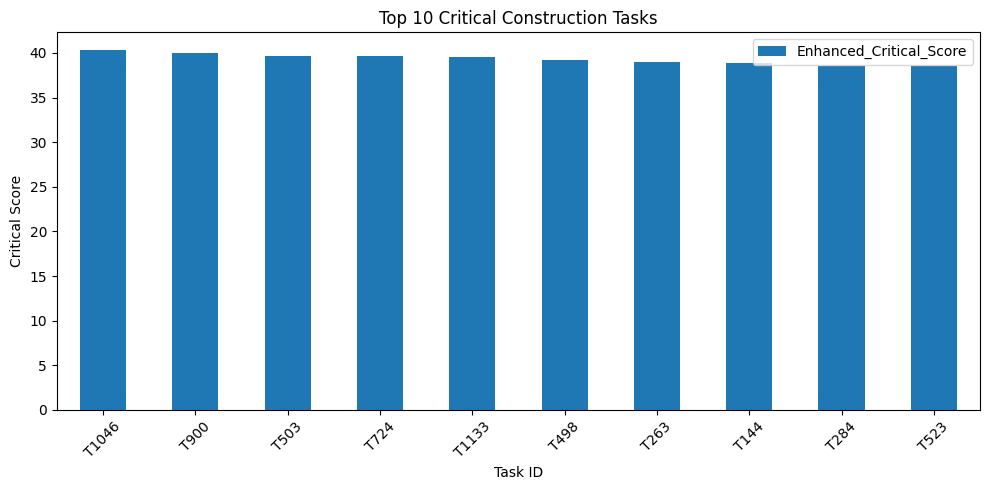

In [16]:
top_tasks = construction.sort_values(
    by="Enhanced_Critical_Score",
    ascending=False
).head(10)

top_tasks.plot(
    x="Task_ID",
    y="Enhanced_Critical_Score",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Critical Construction Tasks")
plt.ylabel("Critical Score")
plt.xlabel("Task ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top 10 Critical Construction Tasks

The chart ranks construction activities using the **Enhanced Critical Task Score**, which combines risk level, dependency count, resource constraints, and site constraints into a single prioritization metric.

### Key Findings

* **Task T1046** received the highest Enhanced Critical Score (**40.3**), making it the most critical activity in the project.
* All top 10 tasks were classified as **High Risk**, indicating strong alignment between the enhanced scoring model and the project's risk assessments.
* The Enhanced Critical Scores range from approximately **38.5 to 40.3**, showing that several tasks have similarly high levels of operational complexity and risk exposure.
* The small differences between task scores suggest that project managers should closely monitor the entire group rather than focusing on a single activity.

### Business Insight

The analysis identified a cluster of high-priority tasks that combine elevated risk levels with operational challenges such as resource constraints, site limitations, and task dependencies. These activities represent potential project bottlenecks and should be prioritized for resource allocation, schedule monitoring, and risk mitigation.

### Conclusion

The Enhanced Critical Task Score successfully highlighted the most critical project activities by integrating multiple dimensions of risk and operational complexity. This approach provides a practical framework for prioritizing management attention and supporting data-driven decision-making in construction project planning.
